In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pymaid
import navis as nv
import numpy as np
import seaborn as sns
import scipy.stats as stats
import statsmodels
import scikit_posthocs as sp
import sys
import scipy
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN




,version,valid,status,is_merged,id,time_stamp,datastack,expires_on
0,1218,True,AVAILABLE,False,1209,2026-05-21 05:10:00,flywire_fafb_production,2026-05-23 04:10:00
1,783,True,AVAILABLE,False,773,2023-09-30 05:10:00,flywire_fafb_production,2121-11-10 07:10:00
2,630,True,AVAILABLE,True,619,2023-03-21 08:10:00,flywire_fafb_production,2121-11-10 07:10:00
3,258,True,AVAILABLE,True,247,2022-01-17 08:10:00,flywire_fafb_production,2121-02-18 08:10:00


In [ ]:
#connect your catmaid instance
instance=pymaid.CatmaidInstance('https://radagast.hms.harvard.edu/catmaidaedes',"")

INFO  : Global CATMAID instance set. Caching is ON. (pymaid)


In [3]:
#MD1
MD1OSNs = pymaid.get_skids_by_annotation(['innervates MD1', 'left palp nerve', 'sensory neuron', 'PSPs done'], allow_partial = False, intersect = True)
MD1OSNsALL = pymaid.get_skids_by_annotation(['innervates MD1', 'left palp nerve', 'sensory neuron'], allow_partial = False, intersect = True)
MD1neurons = pymaid.get_neuron(MD1OSNs)
MD1neuronsALL = pymaid.get_neuron(MD1OSNsALL)

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


Fetch neurons:   0%|          | 0/10 [00:00<?, ?it/s]

Make nrn:   0%|          | 0/10 [00:00<?, ?it/s]

Fetch neurons:   0%|          | 0/45 [00:00<?, ?it/s]

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


Make nrn:   0%|          | 0/45 [00:00<?, ?it/s]

In [ ]:
md1_branch_lengths = []
md1_branch_order_count = []
for neuron in MD1neurons:

    print("**************************************")
    print("**************************************")
    print("this is the number of branches")
    print(nv.segment_analysis(neuron).shape)
    #neuron.reroot(neuron.root, inplace=True)
    branch_order = list(nv.segment_analysis(neuron).groupby('strahler_index').size())
    branch_order.reverse()
    md1_branch_order_count.append(branch_order)
    md1_branch_lengths.append(nv.segment_analysis(neuron).shape[0])
    print("**************************************")
    print("**************************************")


**************************************
**************************************
this is the number of branches
(217, 8)
**************************************
**************************************
**************************************
**************************************
this is the number of branches
(136, 8)
**************************************
**************************************
**************************************
**************************************
this is the number of branches
(130, 8)
**************************************
**************************************
**************************************
**************************************
this is the number of branches
(231, 8)
**************************************
**************************************
**************************************
**************************************
this is the number of branches
(220, 8)
**************************************
**************************************
********************

In [23]:
#MD2
MD2OSNs = pymaid.get_skids_by_annotation(['innervates MD2', 'left palp nerve', 'sensory neuron', 'PSPs done'], allow_partial = False, intersect = True)
MD2OSNsALL = pymaid.get_skids_by_annotation(['innervates MD2', 'left palp nerve', 'sensory neuron'], allow_partial = False, intersect = True)
MD2neurons = pymaid.get_neuron(MD2OSNs)
MD2neuronsALL = pymaid.get_neuron(MD2OSNsALL)

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


Fetch neurons:   0%|          | 0/10 [00:00<?, ?it/s]

Make nrn:   0%|          | 0/10 [00:00<?, ?it/s]

Fetch neurons:   0%|          | 0/45 [00:00<?, ?it/s]

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


Make nrn:   0%|          | 0/45 [00:00<?, ?it/s]

In [ ]:
md2_branch_lengths = []
md2_branch_order_count = []
for neuron in MD2neurons:

    print("**************************************")
    print("**************************************")
    print("this is the number of branches")
    print(nv.segment_analysis(neuron).shape)
    neuron.reroot(neuron.root, inplace=True)
    branch_order = list(nv.segment_analysis(neuron).groupby('strahler_index').size())
    branch_order.reverse()
    md2_branch_order_count.append(branch_order)
    md2_branch_lengths.append(nv.segment_analysis(neuron).shape[0])
    print("**************************************")
    print("**************************************")    

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\1151740223.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  both_connections['connection_type'] = 'both'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\1151740223.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recurrent_connections['connection_type'] = 'recurrent'
C:\Users\wesle\AppData\Local\Temp\ipykern

**************************************
**************************************
this is the number of branches
(111, 8)
**************************************
**************************************


INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\1151740223.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  both_connections['connection_type'] = 'both'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\1151740223.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recurrent_connections['connection_type'] = 'recurrent'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\1151740223.py:12: SettingWithCopyWarning: 
A value is trying to

**************************************
**************************************
this is the number of branches
(57, 8)
**************************************
**************************************


INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\1151740223.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  both_connections['connection_type'] = 'both'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\1151740223.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recurrent_connections['connection_type'] = 'recurrent'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\1151740223.py:12: SettingWithCopyWarning: 
A value is trying to

...

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\1151740223.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  both_connections['connection_type'] = 'both'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\1151740223.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recurrent_connections['connection_type'] = 'recurrent'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\1151740223.py:12: SettingWithCopyWarning: 
A value is trying to

**************************************
**************************************
this is the number of branches
(59, 8)
**************************************
**************************************


INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


**************************************
**************************************
this is the number of branches
(27, 8)
**************************************
**************************************


C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\1151740223.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  both_connections['connection_type'] = 'both'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\1151740223.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recurrent_connections['connection_type'] = 'recurrent'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\1151740223.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

In [25]:
#MD3
MD3OSNs = pymaid.get_skids_by_annotation(['innervates MD3', 'left palp nerve', 'sensory neuron', 'PSPs done'], allow_partial = False, intersect = True)
MD3OSNsALL = pymaid.get_skids_by_annotation(['innervates MD3', 'left palp nerve', 'sensory neuron'], allow_partial = False, intersect = True)
MD3neurons = pymaid.get_neuron(MD3OSNs)
MD3neuronsALL = pymaid.get_neuron(MD3OSNsALL)

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


Fetch neurons:   0%|          | 0/10 [00:00<?, ?it/s]

Make nrn:   0%|          | 0/10 [00:00<?, ?it/s]

Fetch neurons:   0%|          | 0/46 [00:00<?, ?it/s]

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


Make nrn:   0%|          | 0/46 [00:00<?, ?it/s]

In [ ]:
md3_branch_lengths = []
md3_branch_order_count = []
for neuron in MD3neurons:


    print("**************************************")
    print("**************************************")
    print("this is the number of branches")
    print(nv.segment_analysis(neuron).shape)
    neuron.reroot(neuron.root, inplace=True)
    branch_order = list(nv.segment_analysis(neuron).groupby('strahler_index').size())
    branch_order.reverse()
    md3_branch_order_count.append(branch_order)
    md3_branch_lengths.append(nv.segment_analysis(neuron).shape[0])
    print("**************************************")
    print("**************************************")    

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\356361418.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  both_connections['connection_type'] = 'both'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\356361418.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recurrent_connections['con

**************************************
**************************************
this is the number of branches
(99, 8)
**************************************
**************************************


INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\356361418.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  both_connections['connection_type'] = 'both'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\356361418.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recurrent_connections['con

**************************************
**************************************
this is the number of branches
(26, 8)
**************************************
**************************************


INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\356361418.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  both_connections['connection_type'] = 'both'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\356361418.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recurrent_connections['connection_type'] = 'recurrent'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\356361418.py:12: SettingWithCopyWarning: 
A value is trying to be

...

INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\356361418.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  both_connections['connection_type'] = 'both'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\356361418.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recurrent_connections['connection_type'] = 'recurrent'
C:\Users\wesle\AppData\Local\Temp\ipykernel

**************************************
**************************************
this is the number of branches
(53, 8)
**************************************
**************************************


INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)
INFO  : Cached data used. Use `pymaid.clear_cache()` to clear. (pymaid)


**************************************
**************************************
this is the number of branches
(49, 8)
**************************************
**************************************


C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\356361418.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  both_connections['connection_type'] = 'both'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\356361418.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  recurrent_connections['connection_type'] = 'recurrent'
C:\Users\wesle\AppData\Local\Temp\ipykernel_34536\356361418.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

In [29]:
branch_order_df = pd.DataFrame(columns=('glomerulus','branch order','count'))
for neuron in md1_branch_order_count:
    for branch_order, count in  enumerate(neuron):
        branch_order_df = pd.concat([branch_order_df, pd.DataFrame({'glomerulus': 1, 'branch order':branch_order,'count':count},index=[0])],ignore_index=True)
for neuron in md2_branch_order_count:
    for branch_order, count in  enumerate(neuron):
        branch_order_df = pd.concat([branch_order_df, pd.DataFrame({'glomerulus': 2, 'branch order':branch_order,'count':count},index=[0])],ignore_index=True)
for neuron in md3_branch_order_count:
    for branch_order, count in  enumerate(neuron):
        branch_order_df = pd.concat([branch_order_df, pd.DataFrame({'glomerulus': 3, 'branch order':branch_order,'count':count},index=[0])],ignore_index=True)                
branch_order_df

,glomerulus,branch order,count
0,1,0,6
1,1,1,5
2,1,2,43
3,1,3,52
4,1,4,111
...,...,...,...
120,3,3,28
121,3,0,2
122,3,1,9
123,3,2,13


In [159]:
mean_branch_order = branch_order_df.groupby(['glomerulus','branch order']).mean() 

findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.


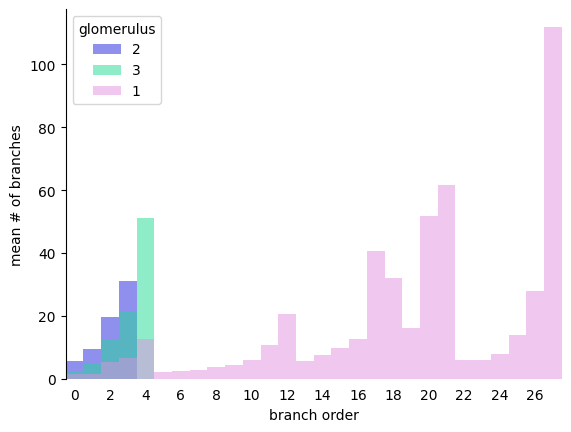

In [252]:
#ax = sns.barplot(mean_branch_order[mean_branch_order['glomerulus']==1],x='branch order', y='count',hue= 'glomerulus',palette=['#EE82EE', '#0000FF', '#00FA9A'],dodge=False,width=1)
ax = sns.barplot(mean_branch_order[mean_branch_order.index.get_level_values(0)==2],x='branch order', y='count',hue= 'glomerulus',palette=['#0000FF'],dodge=False,width=1,alpha=.5)
sns.barplot(mean_branch_order[mean_branch_order.index.get_level_values(0)==3],x='branch order', y='count',hue= 'glomerulus',palette=['#00FA9A'],dodge=False,width=1,alpha=.5)
sns.barplot(mean_branch_order[mean_branch_order.index.get_level_values(0)==1],x='branch order', y='count',hue= 'glomerulus',palette=['#EE82EE'],dodge=False,width=1,alpha=.5)
#outlines
#sns.barplot(mean_branch_order[mean_branch_order.index.get_level_values(0)==2],x='branch order', y='count',hue= 'glomerulus',palette=['#0000FF'],fill=False, dodge=False,width=1,alpha=1)
#sns.barplot(mean_branch_order[mean_branch_order.index.get_level_values(0)==3],x='branch order', y='count',hue= 'glomerulus',palette=['#00FA9A'],fill=False, dodge=False,width=1,alpha=1)
#sns.barplot(mean_branch_order[mean_branch_order.index.get_level_values(0)==1],x='branch order', y='count',hue= 'glomerulus',palette=['#EE82EE'],fill=False, dodge=False,width=1,alpha=1)
ax.set_ylabel("mean # of branches", size=10)
ax.set_xlabel('branch order', size=10, fontname="Liberation Sans")
plt.xticks(range(0,27,2)) 
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.tick_params(axis='y', which='both', left=True, right=False)
sns.despine(fig=None, ax=None, top=True, right=True, left=False, bottom=True, offset=None, trim=False)

plt.savefig('mean_branch_order.svg')

In [34]:
branch_counts =  [md1_branch_lengths,md2_branch_lengths,md3_branch_lengths ]
mean_branch_count = [np.mean(branches) for branches in branch_counts]
branch_count_df = pd.DataFrame(columns=['glomerulus', '# of branches'])
branch_count_points_df = pd.DataFrame(columns=['glomerulus', '# of branches'])

In [38]:
branch_count_df['glomerulus'] = [1,2,3]
branch_count_df['# of branches'] = mean_branch_count
for neuron in md1_branch_lengths:
    neuron_df = pd.DataFrame({'glomerulus': 1, '# of branches': neuron},index=[0])
    branch_count_points_df = pd.concat([branch_count_points_df,neuron_df],ignore_index=True)
for neuron in md2_branch_lengths:
    neuron_df = pd.DataFrame({'glomerulus': 2, '# of branches': neuron},index=[0])
    branch_count_points_df = pd.concat([branch_count_points_df,neuron_df],ignore_index=True)
for neuron in md3_branch_lengths:
    neuron_df = pd.DataFrame({'glomerulus': 3, '# of branches': neuron},index=[0])
    branch_count_points_df = pd.concat([branch_count_points_df,neuron_df],ignore_index=True)        


In [43]:
stats.kruskal(md1_branch_lengths,md2_branch_lengths,md3_branch_lengths,nan_policy='omit')

KruskalResult(statistic=19.33849577214063, pvalue=6.319736908560248e-05)

In [46]:
sp.posthoc_dunn(branch_count_points_df,val_col="# of branches",group_col="glomerulus",p_adjust="bonferroni")

,1,2,3
1,1.000000,0.002876,0.000093
2,0.002876,1.000000,1.000000
3,0.000093,1.000000,1.000000


In [ ]:
stats.kruskal(md1_branch_lengths,md2_branch_lengths,md3_branch_lengths)

findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberati

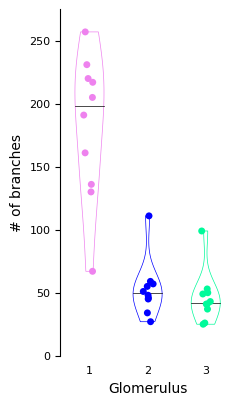

In [124]:
violinplot_dims = (2.25, 4.5)
fig, ax = plt.subplots(figsize=violinplot_dims)
ax = my_violinplot(branch_count_points_df,x='glomerulus',y='# of branches', palette=['#EE82EE', '#0000FF', '#00FA9A'],fill=False, scale='width', cut=0, linewidth=.5, width=.5, inner='line_quart')
sns.stripplot(branch_count_points_df,x='glomerulus',y='# of branches',palette=['#EE82EE', '#0000FF', '#00FA9A'])

ax.set_ylabel("# of branches", size=10)
ax.set_xlabel('Glomerulus', size=10, fontname="Liberation Sans")
plt.xticks(fontsize=8, fontname="Liberation Sans")
plt.yticks(fontsize=8, fontname="Liberation Sans")
#ax.set_aspect(0.01)
plt.ylim(0,275)
plt.tick_params(axis='x', which='both', bottom=False, top=False)
plt.tick_params(axis='y', which='both', left=True, right=False)
sns.despine(fig=None, ax=None, top=True, right=True, left=False, bottom=True, offset=None, trim=False)

plt.savefig('branch_number_bar_plot.svg')